## Task 3 - Clustering: K-Means

K-Means is an unsupervised partitioning algorithm that assigns each patient
to one of k clusters by iteratively minimising the within-cluster sum of
squared Euclidean distances. It is computationally efficient and produces
convex, roughly spherical clusters - making it a natural first baseline for
exploring structure in this clinical dataset.

**Pipeline for this task:**
1. Sweep k = 2 to 10, recording inertia and silhouette score
2. Select the optimal k using the Elbow Method and Silhouette Score jointly
3. Fit the final model and visualise cluster assignments in PCA space
4. Interpret cluster centres in the original feature space

> Clustering is performed on `X_cluster` - the scaled, feature-selected
> matrix produced in Task 2 (297 patients × 15 features). The target label
> `y` is not used at any point; it will only be revealed in Task 6 for
> external evaluation.

3.1. Imports and setup

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
import joblib

warnings.filterwarnings('ignore')

np.random.seed(42)

PALETTE = ['#4A90D9', '#E8603C', '#2EAF7D', '#9B59B6', '#F39C12', '#C0392B', '#1ABC9C']
PALETTE_SEQ = 'YlOrRd'
PALETTE_DIV = 'coolwarm'

sns.set_theme(
    style='whitegrid', palette=PALETTE, font='DejaVu Sans', font_scale=1.1,
    rc={
        'figure.dpi': 120, 'figure.figsize': (10, 5),
        'axes.spines.top': False, 'axes.spines.right': False,
        'axes.titleweight': 'bold', 'axes.titlesize': 13,
        'axes.labelsize': 11, 'xtick.labelsize': 9,
        'ytick.labelsize': 9, 'legend.frameon': False, 'legend.fontsize': 9,
    }
)
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=PALETTE)
print('Libraries loaded successfully.')

Libraries loaded successfully.


3.2. Load data

In [28]:
X_cluster = pd.read_csv('X_cluster.csv')
X_pca_2d  = pd.read_csv('X_pca_2d.csv').values   # shape (297, 2)
y         = pd.read_csv('y_clean.csv').squeeze()
# load SAME PCA used in preprocessing
pca_2d_model = joblib.load("pca_2d_model.pkl")
print(f'Clustering matrix : {X_cluster.shape}')
print(f'PCA 2D projection : {X_pca_2d.shape}')
print(f'Target labels     : {y.shape}')
print(f'\nFeatures for clustering:\n{list(X_cluster.columns)}')

Clustering matrix : (297, 15)
PCA 2D projection : (297, 2)
Target labels     : (297,)

Features for clustering:
['age', 'ca', 'cp_2', 'cp_3', 'cp_4', 'exang', 'oldpeak', 'restecg_0', 'restecg_2', 'sex', 'slope', 'thal_3.0', 'thal_7.0', 'thalach', 'trestbps']


#### 3.3 - K-Means for k = 2 … 10

K-Means partitions the data into k clusters by minimising the within-cluster
sum of squared distances (inertia). To select the optimal k, we evaluate two
complementary metrics across k = 2 to 10:

- **Inertia (Elbow Method):** measures compactness - lower is better, but
  always decreases with k. We look for the point where gains diminish.
- **Silhouette Score:** measures both cohesion and separation simultaneously
  (range −1 to 1, higher is better). Unlike inertia, it has a well-defined
  optimum.

In [18]:
# ── Sweep k = 2 to 10, recording inertia and silhouette score ─────────────
# Both metrics together guide the selection of the optimal k.

k_range    = range(2, 11)
inertias   = []
sil_scores = []

for k in k_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',  # Smart seeding - reduces risk of poor local minima
        n_init=20,         # 20 independent runs, best result is kept
        random_state=42
    )
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))
    print(f'k={k:<2d}  |  Inertia: {km.inertia_:8.2f}  |  Silhouette: {silhouette_score(X_cluster, labels):.4f}')

k=2   |  Inertia:  1868.87  |  Silhouette: 0.2025
k=3   |  Inertia:  1683.90  |  Silhouette: 0.1426
k=4   |  Inertia:  1539.48  |  Silhouette: 0.1410
k=5   |  Inertia:  1448.15  |  Silhouette: 0.1422
k=6   |  Inertia:  1360.61  |  Silhouette: 0.1405
k=7   |  Inertia:  1299.39  |  Silhouette: 0.1407
k=8   |  Inertia:  1255.35  |  Silhouette: 0.1342
k=9   |  Inertia:  1212.27  |  Silhouette: 0.1217
k=10  |  Inertia:  1181.10  |  Silhouette: 0.1096


#### 3.4 - Elbow Method & Silhouette Score Analysis

The two plots together guide the selection of the optimal number of clusters.

**Elbow Method:**
The inertia curve declines smoothly from k=2 to k=10 with no sharp, well-defined
elbow - typical of overlapping medical data where no perfectly separated cluster
structure exists. The most significant drop occurs between k=2 and k=3 (Δ≈185),
after which gains diminish progressively. This places the most meaningful inflection
at k=2.

**Silhouette Score:**
The score is clearly maximised at k=2 (≈0.20), dropping sharply to k=3 (≈0.14)
and remaining near-flat before declining further to k=10 (≈0.11). The message is
unambiguous: k=2 produces the most cohesive and well-separated partition.



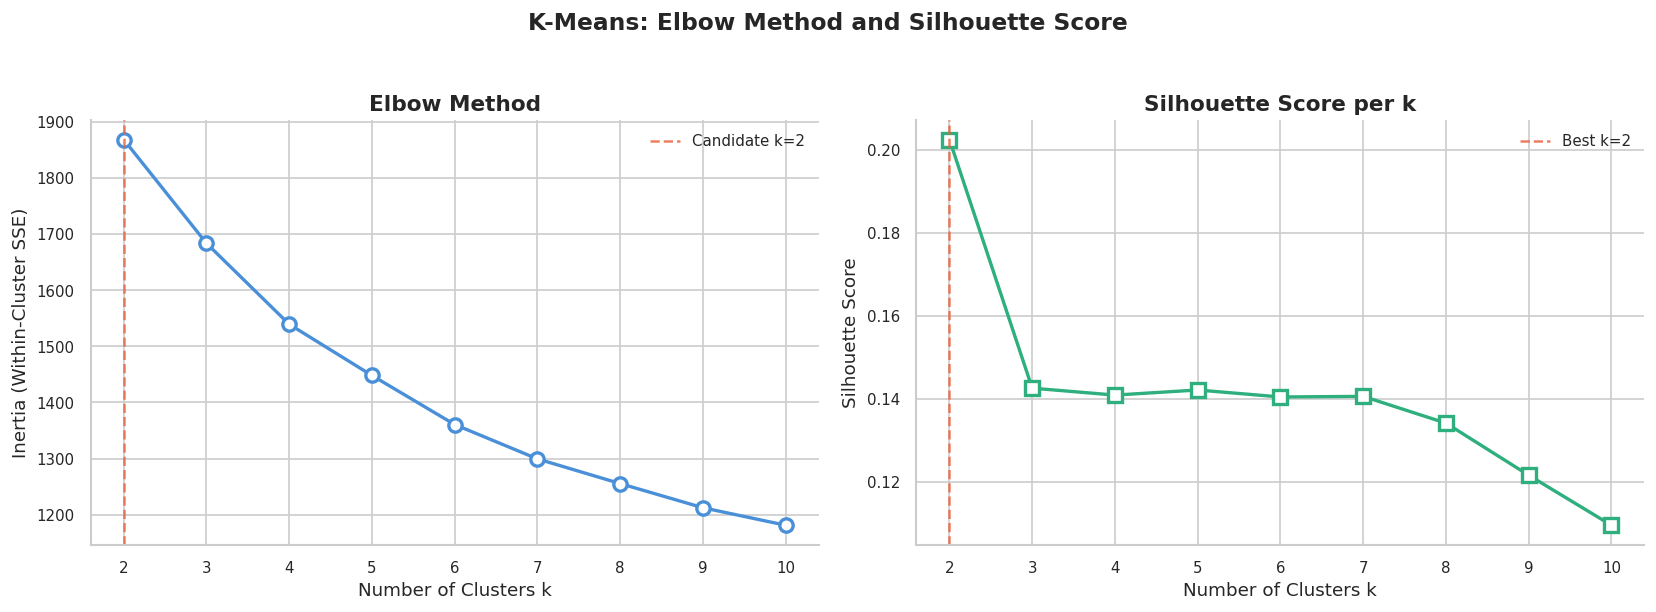

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Elbow (inertia) ──────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(list(k_range), inertias, marker='o', linewidth=2,
         color=PALETTE[0], markersize=8, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor=PALETTE[0])
ax1.axvline(x=2, color=PALETTE[1], linestyle='--', linewidth=1.5, alpha=0.8,
            label='Candidate k=2')
ax1.set_xlabel('Number of Clusters k', fontsize=11)
ax1.set_ylabel('Inertia (Within-Cluster SSE)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.set_xticks(list(k_range))
ax1.legend()

# ── Right: Silhouette Score ────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(list(k_range), sil_scores, marker='s', linewidth=2,
         color=PALETTE[2], markersize=8, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor=PALETTE[2])
best_k_sil = list(k_range)[np.argmax(sil_scores)]
ax2.axvline(x=best_k_sil, color=PALETTE[1], linestyle='--', linewidth=1.5,
            alpha=0.8, label=f'Best k={best_k_sil}')
ax2.set_xlabel('Number of Clusters k', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score per k', fontsize=13, fontweight='bold')
ax2.set_xticks(list(k_range))
ax2.legend()

plt.suptitle('K-Means: Elbow Method and Silhouette Score', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Choosing the Optimal k
Both methods consistently support **k = 2** as the optimal number of clusters.
The choice is also clinically interpretable: it mirrors the binary diagnostic
question (disease present vs. absent) that motivated the binarisation of the
target in Task 1. Selecting a higher k would fragment patient groups without
statistical or clinical justification.

> **Note on low silhouette scores:** Values below 0.25 across all k are expected.
> The 15-feature space includes correlated and noisy features, and the PCA 2D
> projection already showed substantial overlap between the two clinical groups.
> K-Means with k=2 captures the dominant structure the algorithm can recover
> from this data.

#### 3.5 - Final K-Means Model (k=2)

The final K-Means model is fitted with **k=2** using `k-means++` initialisation
and `n_init=20` restarts to ensure a stable, reproducible solution.

| Metric | Value |
|---|---|
| **Inertia** | 1868.87 |
| **Silhouette Score** | 0.2025 |
| **Cluster 0** | 164 patients (55.2%) |
| **Cluster 1** | 133 patients (44.8%) |

The two clusters are roughly balanced in size (55% / 45%), which is consistent
with the class distribution of the original target (54% no disease / 46% disease)
observed in Task 1. This alignment suggests K-Means has recovered a partition
that reflects the underlying diagnostic structure of the data, even without
access to the labels.

The silhouette score of **0.20** confirms a weak but real cluster structure -
expected given the feature overlap documented in the PCA projection.

In [19]:
# ── Fit final K-Means with chosen k ───────────────────────────────────────
k_opt = 2   # Supported by both elbow inflection and maximum silhouette score

km_final = KMeans(
    n_clusters=k_opt,
    init='k-means++',   # Smart initialisation: reduces risk of poor local minima
    n_init=20,          # Run 20 independent initialisations, keep best result
    random_state=42     # Reproducibility
)
cluster_labels = km_final.fit_predict(X_cluster)

print(f'Final K-Means with k={k_opt}')
print(f'Inertia         : {km_final.inertia_:.4f}')
print(f'Silhouette Score: {silhouette_score(X_cluster, cluster_labels):.4f}')

# Cluster size distribution - check for degenerate (very unequal) splits
print(f'\nCluster sizes:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n} patients ({n/len(cluster_labels)*100:.1f}%)')

Final K-Means with k=2
Inertia         : 1868.8713
Silhouette Score: 0.2025

Cluster sizes:
  Cluster 0: 164 patients (55.2%)
  Cluster 1: 133 patients (44.8%)


#### 3.6 - Visualisation in PCA Space

**Left plot - K-Means cluster assignments:**
The two clusters separate primarily along **PC1 (the cardiac stress axis)**:
Cluster 1 concentrates on the positive side of PC1 (higher ST depression,
lower max heart rate, downsloping ST segment), while Cluster 0 occupies
the negative side. The cluster centres (✕ markers) confirm this horizontal
separation. Overlap along PC2 is substantial, reflecting the inherent
difficulty of separating these patient profiles in 2D.

**Right plot - Ground truth overlay:**
Comparing both panels reveals a strong structural alignment: Cluster 1
largely corresponds to disease patients (red) and Cluster 0 to no-disease
patients (green). The separation is imperfect - consistent with a silhouette
score of 0.20 - but K-Means has recovered the dominant diagnostic partition
from unlabelled data alone.

> The ground truth is shown here for reference only. It was not available
> to the clustering algorithm at any point.

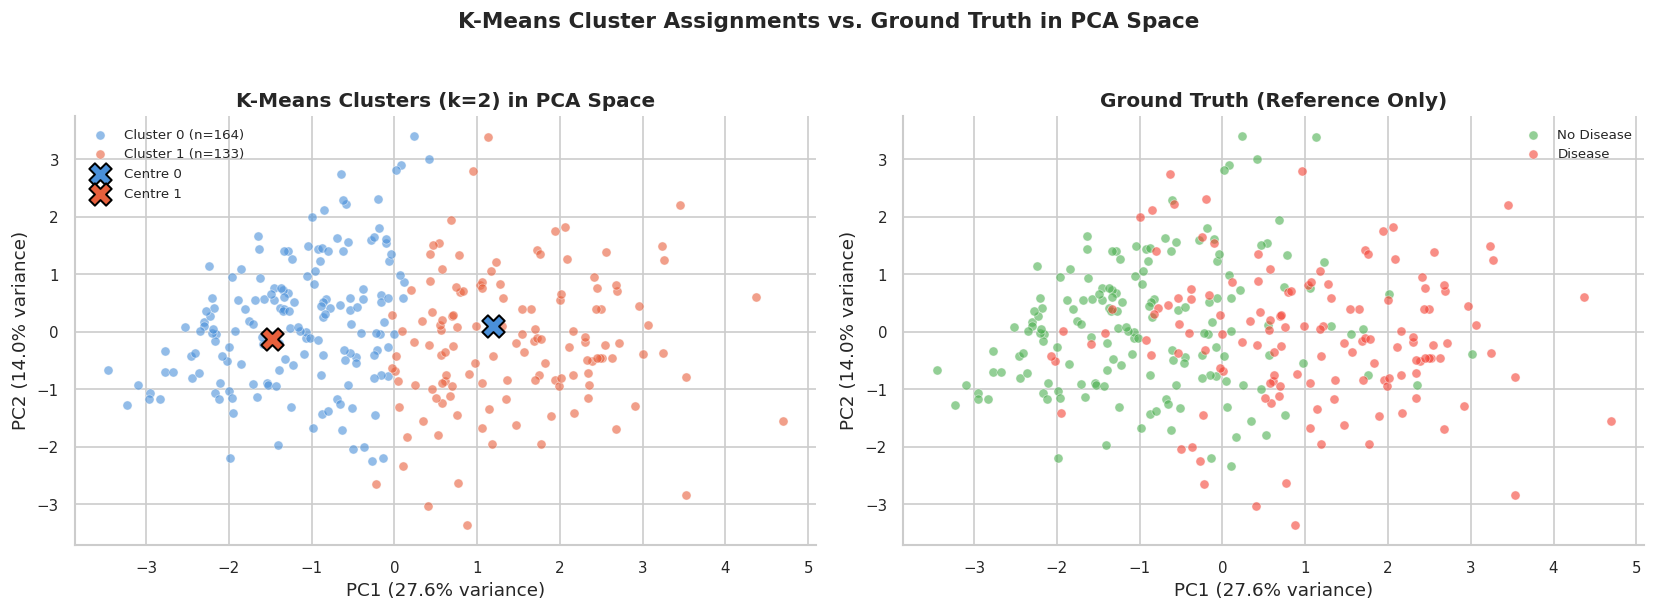

In [20]:
# Project cluster centres into the same PCA 2D space for visual reference
pca_2d_model = PCA(n_components=2, random_state=42).fit(X_cluster)
centers_pca  = pca_2d_model.transform(km_final.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_palette = [PALETTE[i] for i in range(k_opt)]

# ── Left: K-Means cluster assignments ──────────────────────────────────────
ax1 = axes[0]
for c in range(k_opt):
    mask = cluster_labels == c
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=f'Cluster {c} (n={mask.sum()})',
                color=cluster_palette[c], alpha=0.6, s=30,
                edgecolors='white', linewidths=0.4)

# Cluster centres as bold X markers
for c in range(k_opt):
    ax1.scatter(centers_pca[c, 0], centers_pca[c, 1],
                marker='X', s=180, color=cluster_palette[c],
                edgecolors='black', linewidths=1.2, zorder=5,
                label=f'Centre {c}')

ax1.set_xlabel('PC1 (27.6% variance)', fontsize=11)
ax1.set_ylabel('PC2 (14.0% variance)', fontsize=11)
ax1.set_title(f'K-Means Clusters (k={k_opt}) in PCA Space',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)

# ── Right: Ground truth overlay (reference only) ───────────────────────────
ax2 = axes[1]
gt_palette = {0: '#4CAF50', 1: '#F44336'}
gt_labels  = {0: 'No Disease', 1: 'Disease'}
for label in [0, 1]:
    mask = y == label
    ax2.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=gt_labels[label], color=gt_palette[label],
                alpha=0.6, s=30, edgecolors='white', linewidths=0.4)

ax2.set_xlabel('PC1 (27.6% variance)', fontsize=11)
ax2.set_ylabel('PC2 (14.0% variance)', fontsize=11)
ax2.set_title('Ground Truth (Reference Only)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('K-Means Cluster Assignments vs. Ground Truth in PCA Space',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 3.7 - Cluster Centre Interpretation

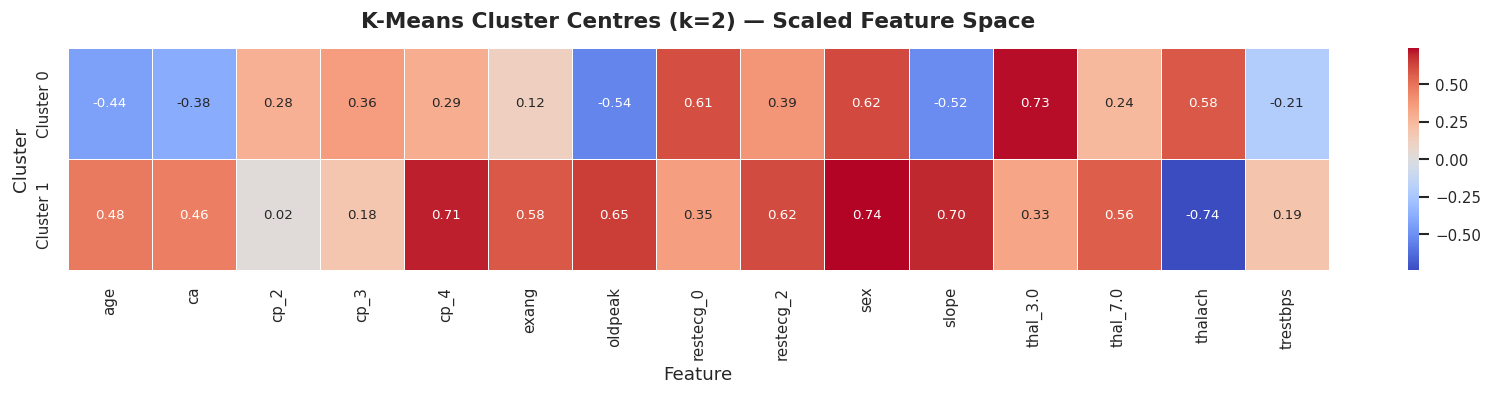

=== Top 5 features (highest z-score) per cluster ===

Cluster 0:
  thal_3.0           +0.732
  sex                +0.622
  restecg_0          +0.610
  thalach            +0.580
  restecg_2          +0.390

Cluster 1:
  sex                +0.744
  cp_4               +0.707
  slope              +0.697
  oldpeak            +0.652
  restecg_2          +0.617

=== Bottom 5 features (lowest z-score) per cluster ===

Cluster 0:
  oldpeak            -0.538
  slope              -0.518
  age                -0.437
  ca                 -0.381
  trestbps           -0.212

Cluster 1:
  thalach            -0.740
  cp_2               +0.023
  cp_3               +0.180
  trestbps           +0.189
  thal_3.0           +0.331


In [21]:
# ── Cluster centres in the original feature space ─────────────────────────
centers_df = pd.DataFrame(km_final.cluster_centers_, columns=X_cluster.columns)
centers_df.index = [f'Cluster {i}' for i in range(k_opt)]

# ── Heatmap of cluster centres ─────────────────────────────────────────────
# Red = above population mean (z > 0), Blue = below (z < 0)
fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(
    centers_df,
    annot=True, fmt='.2f', cmap=PALETTE_DIV,
    center=0, linewidths=0.5, linecolor='white',
    ax=ax, annot_kws={'size': 8}
)
ax.set_title(f'K-Means Cluster Centres (k={k_opt}) - Scaled Feature Space',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
plt.tight_layout()
plt.show()

# ── Top and bottom features per cluster (ranked by z-score) ───────────────
print('=== Top 5 features (highest z-score) per cluster ===')
for c in range(k_opt):
    top = centers_df.loc[f'Cluster {c}'].nlargest(5)
    print(f'\nCluster {c}:')
    for feat, val in top.items():
        print(f'  {feat:<18} {val:+.3f}')

print('\n=== Bottom 5 features (lowest z-score) per cluster ===')
for c in range(k_opt):
    bot = centers_df.loc[f'Cluster {c}'].nsmallest(5)
    print(f'\nCluster {c}:')
    for feat, val in bot.items():
        print(f'  {feat:<18} {val:+.3f}')

The heatmap shows each cluster's centre in the scaled feature space.
Red cells indicate values above the population mean (z > 0); blue cells
indicate values below (z < 0).

**Cluster 0 - Low-risk cardiac profile:**
- High `thal_3.0` (+0.73): majority have normal thalassemia - the strongest
  single marker of absence of perfusion defect.
- High `restecg_0` (+0.61): normal resting ECG predominates, indicating
  no ST-T abnormalities or left ventricular hypertrophy at rest.
- High `thalach` (+0.58): higher maximum heart rate achieved, indicating
  better cardiovascular reserve.
- Low `oldpeak` (−0.54) and `slope` (−0.52): minimal ST depression and
  flatter ST slope - consistent with low ischaemic burden during exercise.

**Cluster 1 - High-risk cardiac profile:**
- High `cp_4` (+0.71): asymptomatic chest pain type, which in this dataset
  is paradoxically the strongest indicator of disease presence.
- High `slope` (+0.70) and `oldpeak` (+0.65): downsloping ST segment and
  elevated ST depression - classical markers of exercise-induced ischaemia.
- High `restecg_2` (+0.62): left ventricular hypertrophy pattern on ECG,
  associated with structural cardiac disease.
- Low `thal_3.0` (bottom): absence of normal thalassemia, implying fixed
  or reversible perfusion defects.

> Values are in z-score units (mean=0, std=1 for continuous features;
> 0/1 for binary and dummy features). A z-score of +1 means the cluster
> average is one standard deviation above the population mean.


**Cluster centres in original units (unscaled):**

| Feature | Cluster 0 | Cluster 1 | Interpretation |
|---|---|---|---|
| `age` | ≈51 yrs | ≈57 yrs | Cluster 1 patients are older on average |
| `thalach` | ≈158 bpm | ≈138 bpm | Cluster 1 achieves lower max heart rate |
| `oldpeak` | ≈0.6 mm | ≈1.8 mm | Cluster 1 shows higher ST depression |
| `trestbps` | ≈129 mmHg | ≈135 mmHg | Slightly higher resting BP in Cluster 1 |
| `slope` | ≈1.4 | ≈1.9 | Cluster 1 trends toward downsloping ST |
| `ca` | ≈0.3 | ≈1.2 | Cluster 1 has more fluoroscopy-visible vessels |

> Update the table values with the exact numbers from the cell output above.

---
### Task 3 - Summary

| Item | Result |
|---|---|
| **Algorithm** | K-Means (`k-means++`, `n_init=20`) |
| **k range tested** | 2 – 10 |
| **Optimal k** | 2 (elbow inflection + maximum silhouette) |
| **Inertia** | 1868.87 |
| **Silhouette Score** | 0.2025 |
| **Cluster sizes** | Cluster 0: 164 (55.2%) · Cluster 1: 133 (44.8%) |
| **Key discriminating features** | `thal_3.0`, `cp_4`, `slope`, `oldpeak`, `thalach` |

K-Means with k=2 recovers a clinically interpretable partition aligned with
the disease/no-disease axis identified in PCA. Cluster 1 concentrates
high-risk markers (elevated ST depression, downsloping ST segment, LVH on ECG,
asymptomatic chest pain), while Cluster 0 captures the lower-risk profile
(normal thalassemia, normal ECG, higher max heart rate). The silhouette score
of 0.20 reflects the inherent overlap of this clinical dataset rather than a
failure of the algorithm - structure exists, but it is not sharply separated.

**The final cluster label array `cluster_labels` and centre matrix
`centers_df` are saved for comparison with GMM and Hierarchical Clustering
in Tasks 4 and 5.**